<h1>Etape 5 : Interprétation et Visualisation</h1>
Dans ce notebook, nous allons extraire les données enrichies et les afficher, les comparer sous forme graphique 

<h2>Chargement des données</h2>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Chargement des données
df = pd.read_csv("cves_enriched_local.csv")

# Nettoyage rapide
df = df.dropna(subset=["Score CVSS", "Score EPSS"])
df = df[df["Score CVSS"] != "Non disponible"]
df = df[df["Score EPSS"] != "Non disponible"]
df["Score CVSS"] = df["Score CVSS"].astype(float)
df["Score EPSS"] = df["Score EPSS"].astype(float)

<h3>Nombre de vulnérabilités par score cvss</h3>

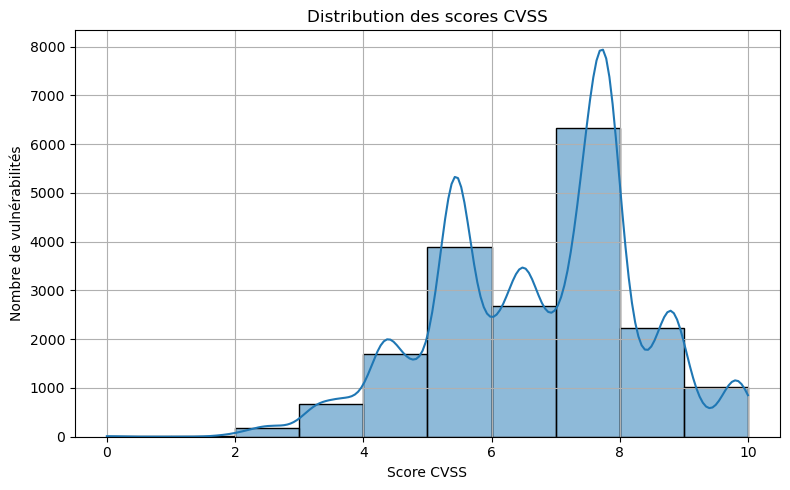

In [13]:
# Histogramme des scores Score CVSS
plt.figure(figsize=(8, 5))
sns.histplot(df["Score CVSS"], bins=10, kde=True)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid(True)
plt.tight_layout()
plt.savefig("cvss_distribution.png")
plt.show()

On peut voir qu'il y a beaucoup de vulnérabilités dans la fourchette moyenne-haute, avec la courbe pour nous représenter le score de manière plus précise car il y a des décimales

<h3>On cherche à savoir s'il y a une relation entre probabilité d'exploitation d'une vulnérabilité et la gravité de celle-ci</h3>

C:\Users\antoi\AppData\Local\Temp\ipykernel_13548\6212865.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()


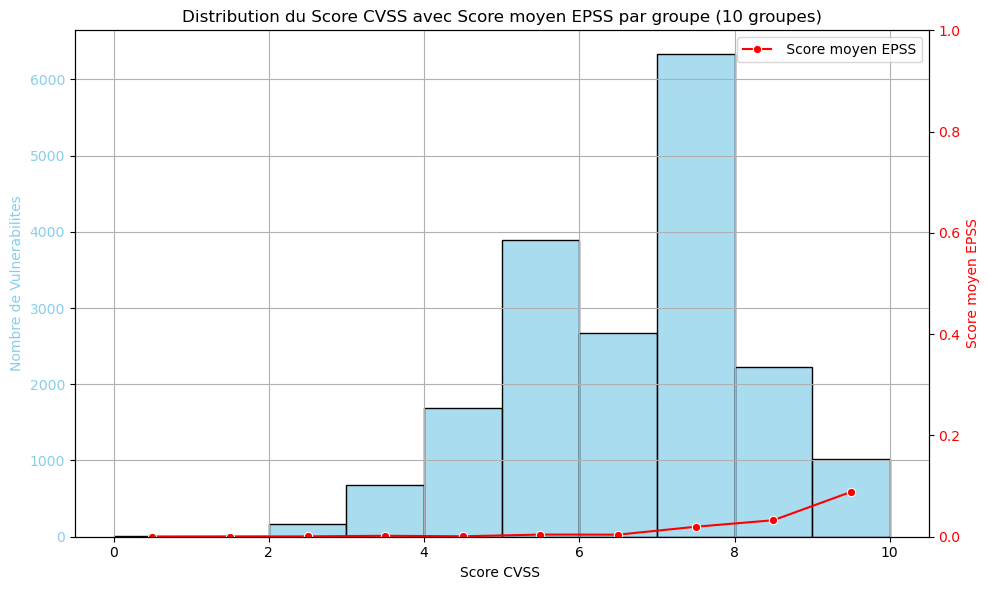

In [45]:
df['cvss_bin'] = pd.cut(df['Score CVSS'], bins=10)
#score moyen epss par note cvss

epss_means = df.groupby('cvss_bin')['Score EPSS'].mean().reset_index()
epss_means['cvss_mid'] = epss_means['cvss_bin'].apply(lambda x: x.mid)
fig, ax1 = plt.subplots(figsize=(10, 6))

# axe gauche
sns.histplot(df['Score CVSS'], bins=10, kde=False, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('Score CVSS ')
ax1.set_ylabel('Nombre de Vulnerabilites', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True)

# axe droit (right axis)
ax2 = ax1.twinx()
sns.lineplot(x='cvss_mid', y='Score EPSS', data=epss_means, 
             ax=ax2, color='red', marker='o', label=' Score moyen EPSS')
ax2.set_ylabel('Score moyen EPSS', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)  # Score EPSS ranges from 0 to 1

plt.title('Distribution du Score CVSS avec Score moyen EPSS par groupe (10 groupes)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("cvss_distribution_with_epss.png")
plt.show()

On peut voir que la courbe reste assez basse jusqu'à 6 de CVSS puis elle monte de plus en plus. On peut aussi noter qu'entre le Score 8 et 10, 
il y a moins de vulnérabilités, mais qu'elles ont plus de chances d'être exploitées. Il est aussi important de noter que ce sont des moyennes et l'EPSS peut donc varier en fonction d'autres facteurs tels que le type d'attaque ou de produit.

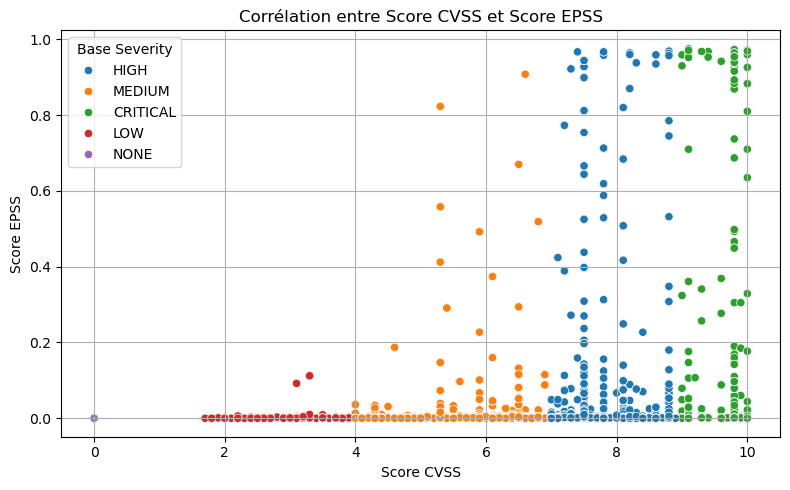

In [15]:
# Nuage de points Score CVSS vs Score EPSS
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Score CVSS", y="Score EPSS", data=df, hue="Base Severity")
plt.title("Corrélation entre Score CVSS et Score EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_cvss_epss.png")
plt.show()

Sur ce nuage de points, on peut voir que la plupart des points sont en bas mais qu'il commence à 
avoir des points à 1 entre les cvss de 7 à 10 ce qui explique pourquoi la moyenne monte.

<h2>Cameberts du top 10 des types de vulnérabilités</h2>


avec type cwe

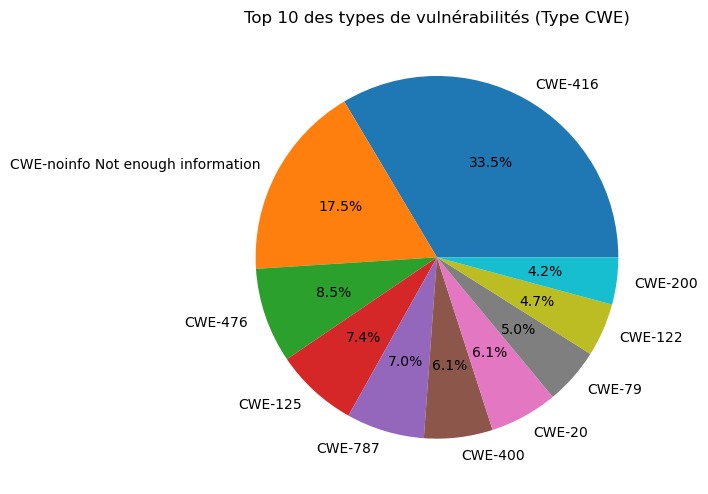

In [8]:
# Filtrer les valeurs 'non disponibles'
df_filtered = df[df["Type CWE"] != 'Non disponible']

# Obtenir les 10 types CWE les plus fréquents
top_cwe = df_filtered["Type CWE"].value_counts().head(10)

# Créer le diagramme circulaire
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (Type CWE)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("cwe_pie.png")
plt.show()

avec description cwe


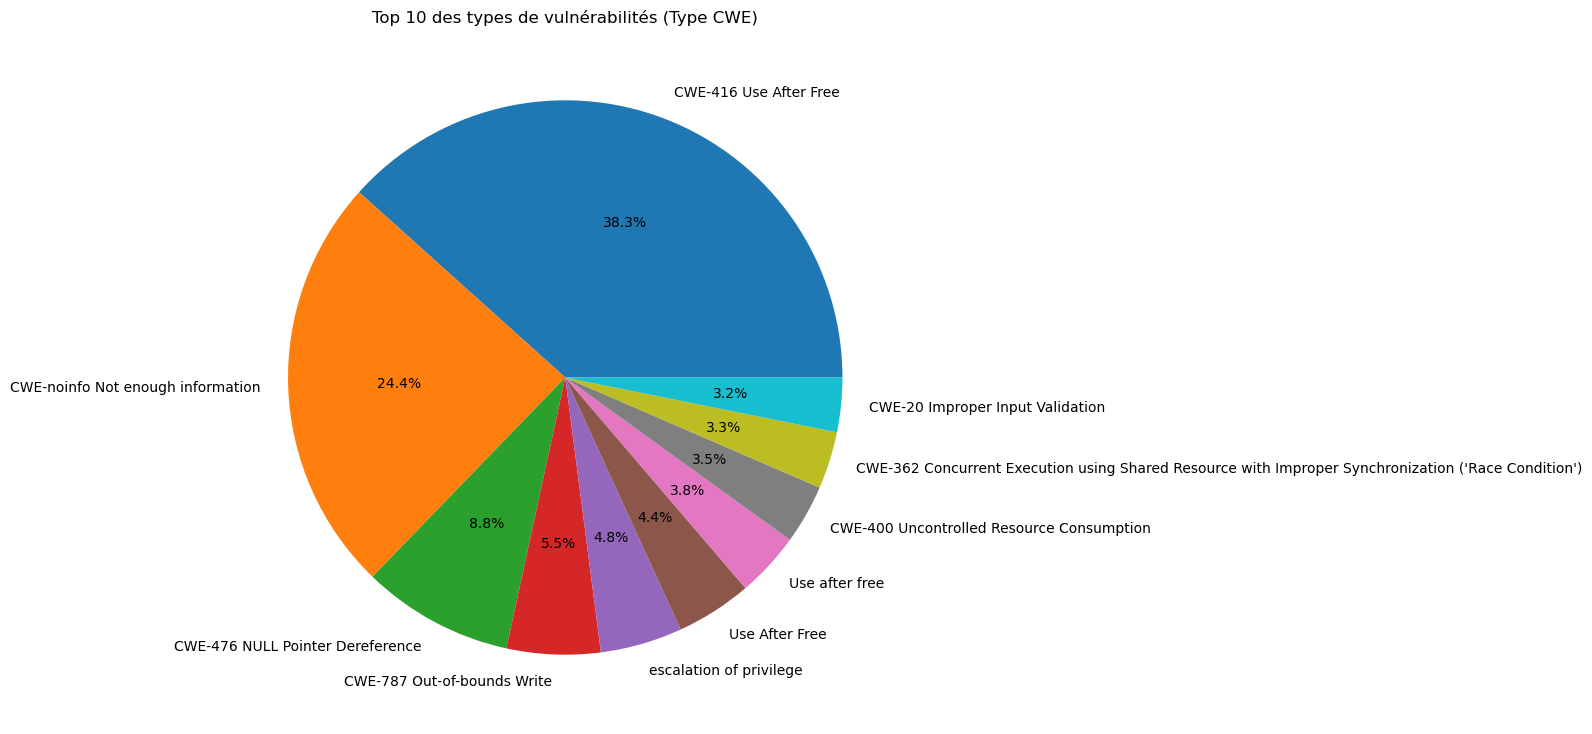

In [11]:
# Diagramme circulaire des types Type CWE (pareil que celui d'avant mais avec les noms d'attaque)
df_filtered = df[df["Description CWE"] != 'Non disponible']
top_cwe = df_filtered["Description CWE"].value_counts().head(10)
plt.figure(figsize=(9, 9))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (Type CWE)")
plt.ylabel("")

plt.savefig("cwe_desc_pie.png")
plt.show()

on peut voir que la vulnérabilité largement dominante est CWE-416 Use After Free qui correspond à l'utilisation d'un emplacement mémoire d'une machine après qu'il a été libéré.

<h2>Quelles attaques sont les plus graves ?</h2>

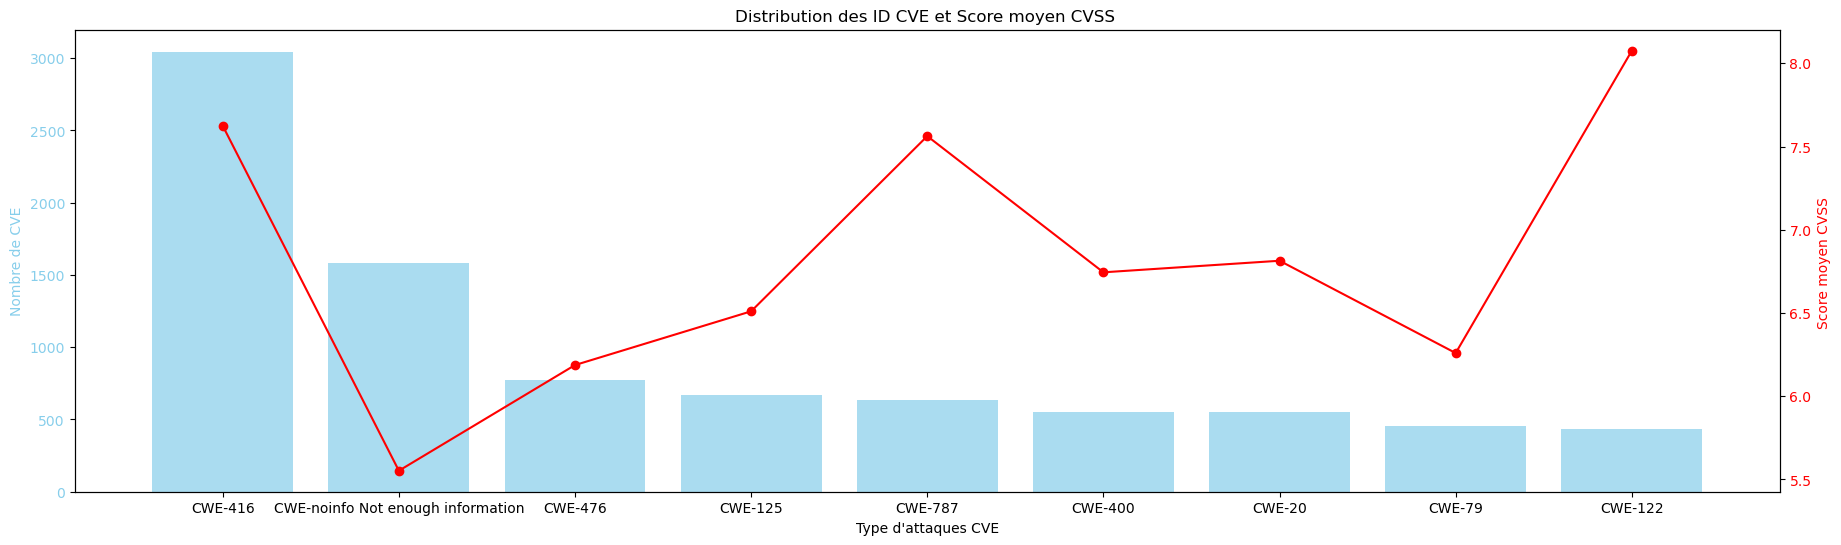

In [26]:

#rapport entre type d'attaques et sévérité
#filtre et tri
attack_stats = df.groupby('Type CWE').agg(
    count=('Identifiant CVE', 'size'),
    mean_cvss=('Score CVSS', 'mean')
).sort_values(by='count', ascending=False).reset_index().head(10)
attack_stats=attack_stats[attack_stats["Type CWE"] != 'Non disponible']
fig, ax1 = plt.subplots(figsize=(22, 6))
# Bar plot 
ax1.bar(attack_stats['Type CWE'], attack_stats['count'], color='skyblue', alpha=0.7, label='nombre de CVE')
ax1.set_xlabel('Type d\'attaques CVE')
ax1.set_ylabel('Nombre de CVE', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
#line plot
ax2 = ax1.twinx()
ax2.plot(attack_stats['Type CWE'], attack_stats['mean_cvss'], color='red', marker='o', label='Mean Score CVSS')
ax2.set_ylabel('Score moyen CVSS ', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Distribution des ID CVE et Score moyen CVSS ')
plt.savefig("mean_cvss_per_cve.png")
plt.show()

on remarque que les attaques les plus graves sont CWE-416,CWE-122 et CWE-787 avec une moyenne CVSS de 7,5

<h3>Produits les plus affectés par les vulnérabilités</h3>

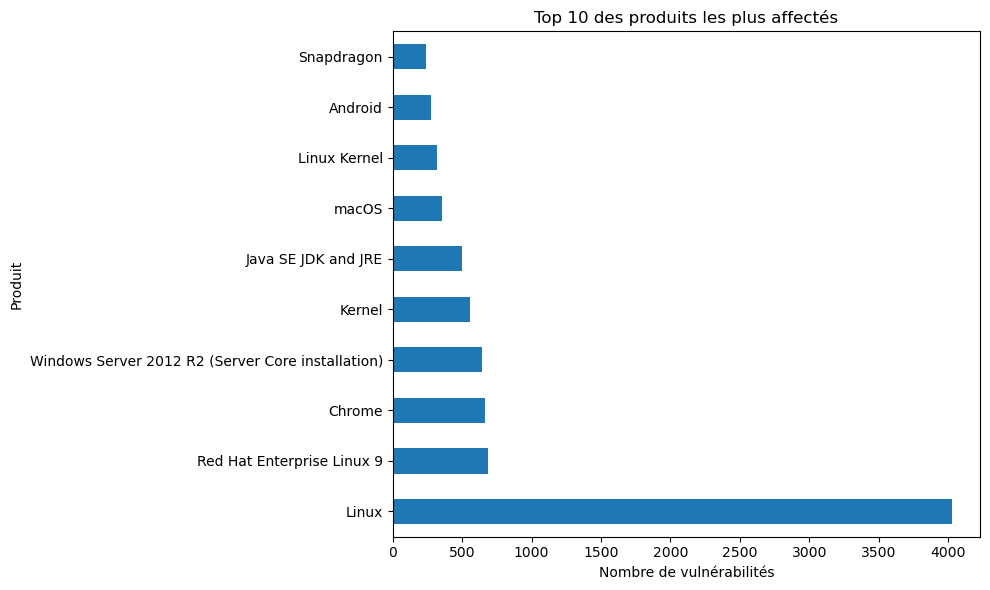

In [17]:
# Produits les plus affectés
plt.figure(figsize=(10, 6))
df_filtered = df[df["Produit"] != 'Non disponible']
df_filtered["Produit"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

Ici, on observe que la plupart des vulnérabilités viennent de Linux suivis par Chrome et Windows 2012

<h2>On cherche à connaître la tendance des vulnérabilités au cours du temps</h2>

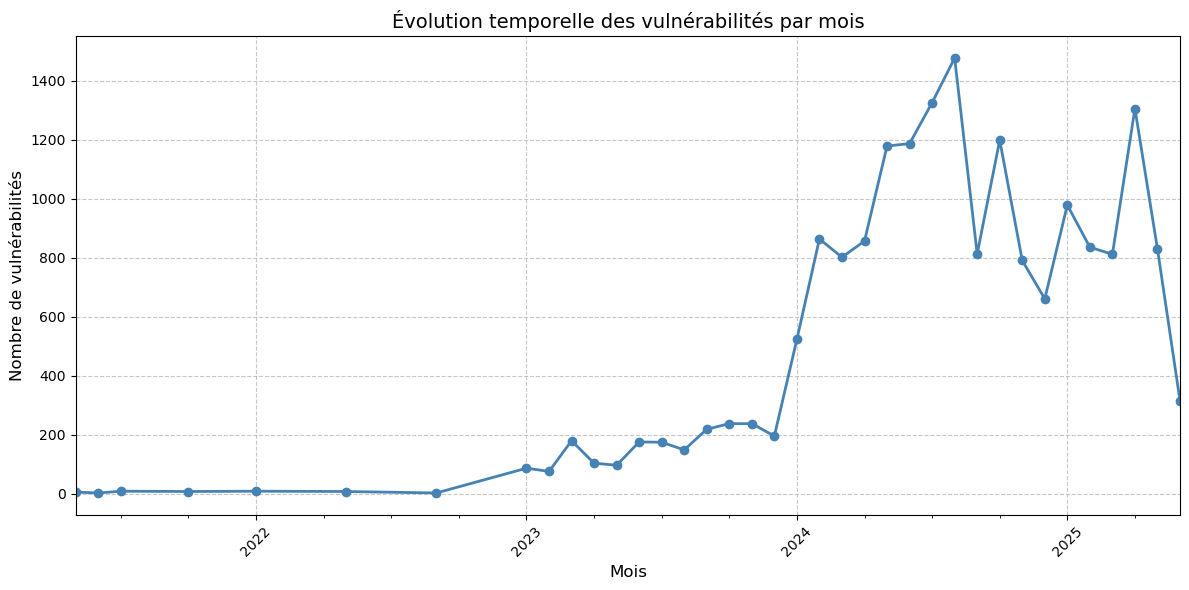

In [28]:
# Conversion date
try:
   #iso
    df["Date de publication"] = pd.to_datetime(df["Date de publication"], format='ISO8601')
except ValueError:
    try:
        # split la chaine
        df["Date de publication"] = pd.to_datetime(df["Date de publication"].str.split('T').str[0])
    except AttributeError:
        # methode plus generale
        df["Date de publication"] = pd.to_datetime(df["Date de publication"], format='mixed')

df_by_month = df.groupby(df["Date de publication"].dt.to_period("M")).size()
plt.figure(figsize=(12, 6))
df_by_month.plot(kind="line", marker="o", color='steelblue', linewidth=2)
plt.title("Évolution temporelle des vulnérabilités par mois", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nombre de vulnérabilités", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On voit qu'il y a une augmentation nette des vulnérabilités à partir de l'année 2024

<h3>Probabilité EPSS par an</h3>

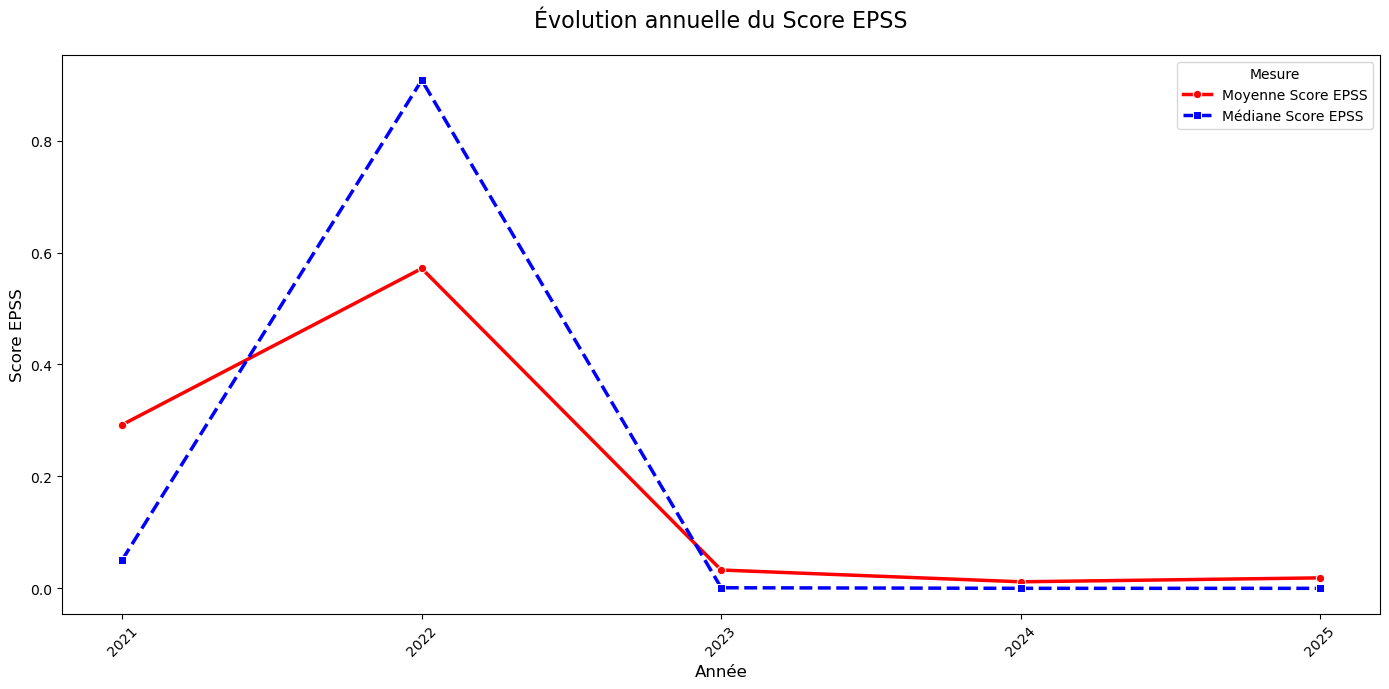

In [32]:
# Conversion des dates et des scores
df['Date de publication'] = pd.to_datetime(df['Date de publication'], errors='coerce')
df['year'] = df['Date de publication'].dt.to_period('Y')
df['Score EPSS'] = pd.to_numeric(df['Score EPSS'], errors='coerce')

# Statistiques annuelles (on ne garde que les années avec au moins 5 entrées)
year_stats = df.groupby('year')['Score EPSS'].agg(['mean', 'median', 'count']).reset_index()
year_stats = year_stats[year_stats['count'] >= 5]
year_stats['year'] = year_stats['year'].astype(str)  # Pour affichage clair sur l'axe X

# Visualisation
plt.figure(figsize=(14, 7))
sns.lineplot(x='year', y='mean', data=year_stats, 
             marker='o', color='red', linewidth=2.5, label='Moyenne Score EPSS')
sns.lineplot(x='year', y='median', data=year_stats,
             marker='s', color='blue', linewidth=2.5, linestyle='--', label='Médiane Score EPSS')

plt.title('Évolution annuelle du Score EPSS', fontsize=16, pad=20)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Score EPSS', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Mesure')
plt.tight_layout()
plt.savefig('epss_trend_by_year.png', dpi=300, bbox_inches='tight')
plt.show()


 de manière paradoxale, le score epss est plus élevé en 2021-2022 qu'en 2024-2025, que ce soit la moyenne ou la mediane, ce qui signifie que les vulnérabilités ont augmenté mais que la probabilité de les exploiter a diminué 

<h2>On cherche l'EPSS par produit pour savoir si le nombre de vulnérabilités correspond</h2>

C:\Users\antoi\AppData\Local\Temp\ipykernel_13548\3172159620.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=product_stats.index, y='mean', data=product_stats,
C:\Users\antoi\AppData\Local\Temp\ipykernel_13548\3172159620.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  points = sns.pointplot(x=product_stats.index, y='max', data=product_stats,


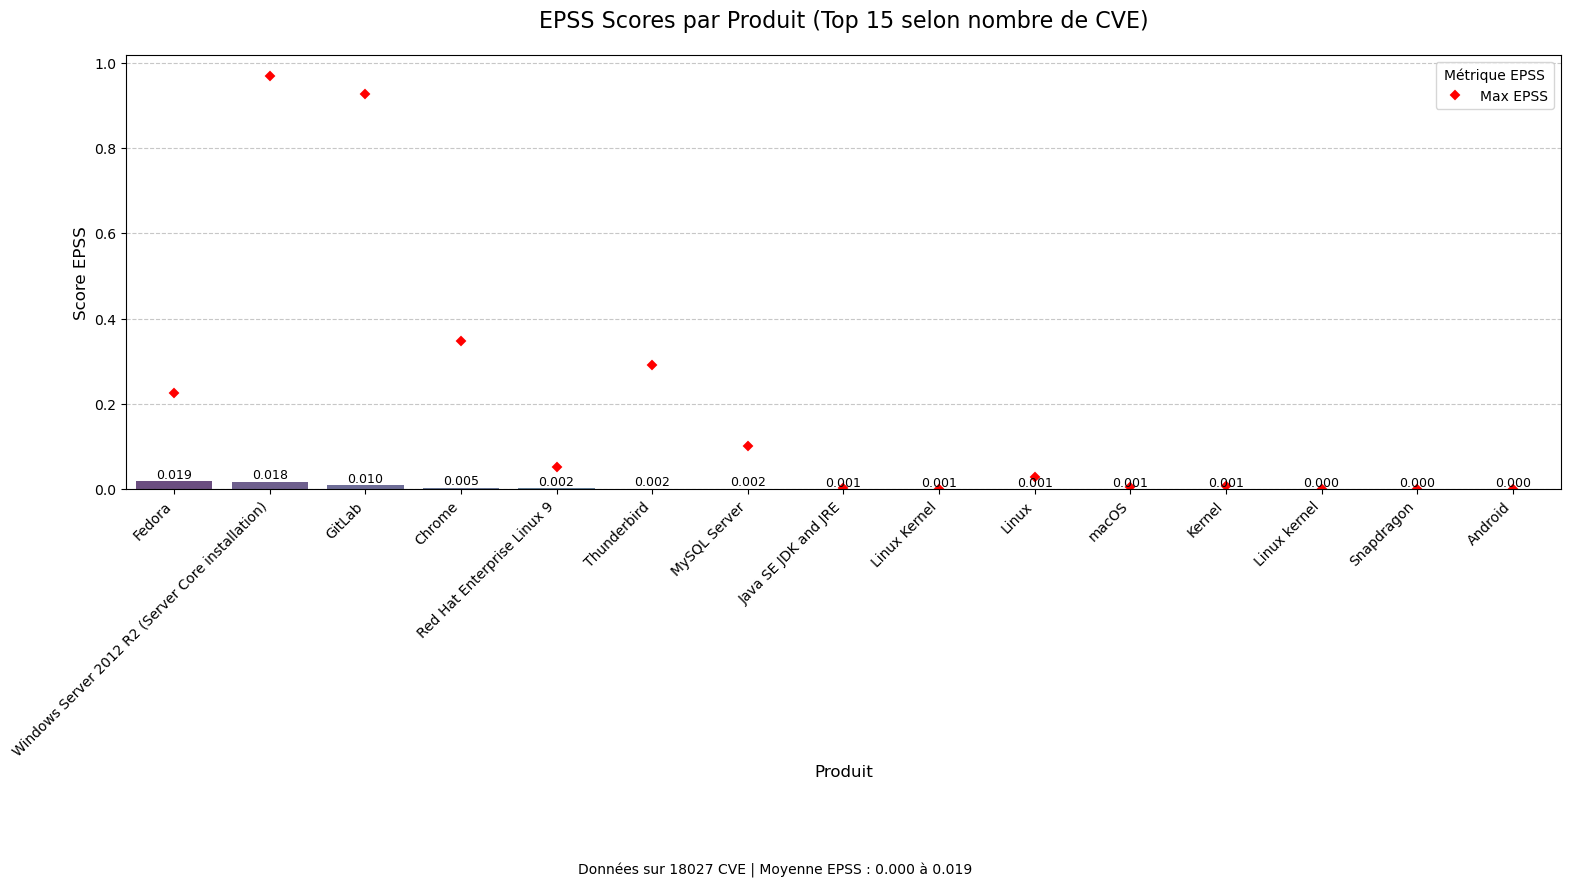

In [51]:
# Nettoyage des données
df['Score EPSS'] = pd.to_numeric(df['Score EPSS'], errors='coerce')
df = df.dropna(subset=['Score EPSS'])  # Supprimer les EPSS manquants
df = df[df['Produit'].notna() & (df['Produit'] != 'Non disponible')]  # Supprimer les produits non renseignés

# Top 15 produits les plus fréquents
top_products = df['Produit'].value_counts().head(15).index

# Calcul des statistiques EPSS par produit
product_stats = df[df['Produit'].isin(top_products)].groupby('Produit')['Score EPSS'].agg(
    ['mean', 'median', 'count', 'max']
).sort_values('mean', ascending=False)

# Visualisation
plt.figure(figsize=(16, 8))

bars = sns.barplot(x=product_stats.index, y='mean', data=product_stats, 
                   palette='viridis', alpha=0.8)

# Ajouter les valeurs au-dessus des barres
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Ajouter les max sous forme de points rouges
points = sns.pointplot(x=product_stats.index, y='max', data=product_stats,
                       color='red', markers='D', linestyles='', scale=0.7,
                       label='Max EPSS')

plt.title('EPSS Scores par Produit (Top 15 selon nombre de CVE)', fontsize=16, pad=20)
plt.xlabel('Produit', fontsize=12)
plt.ylabel('Score EPSS', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Métrique EPSS')
plt.tight_layout()

# Texte descriptif
plt.figtext(0.5, -0.1, 
            f"Données sur {len(df)} CVE | Moyenne EPSS : {product_stats['mean'].min():.3f} à {product_stats['mean'].max():.3f}", 
            ha='center', fontsize=10)

plt.savefig('epss_by_product.png', dpi=300, bbox_inches='tight')
plt.show()


On voit que Linux figure dans le top 4 en score epss, et que le 1er est Fedora. 

<h2>On cherche à connaître les scores cvss par éditeur/vendeur</h2>

C:\Users\antoi\AppData\Local\Temp\ipykernel_13548\1987000475.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


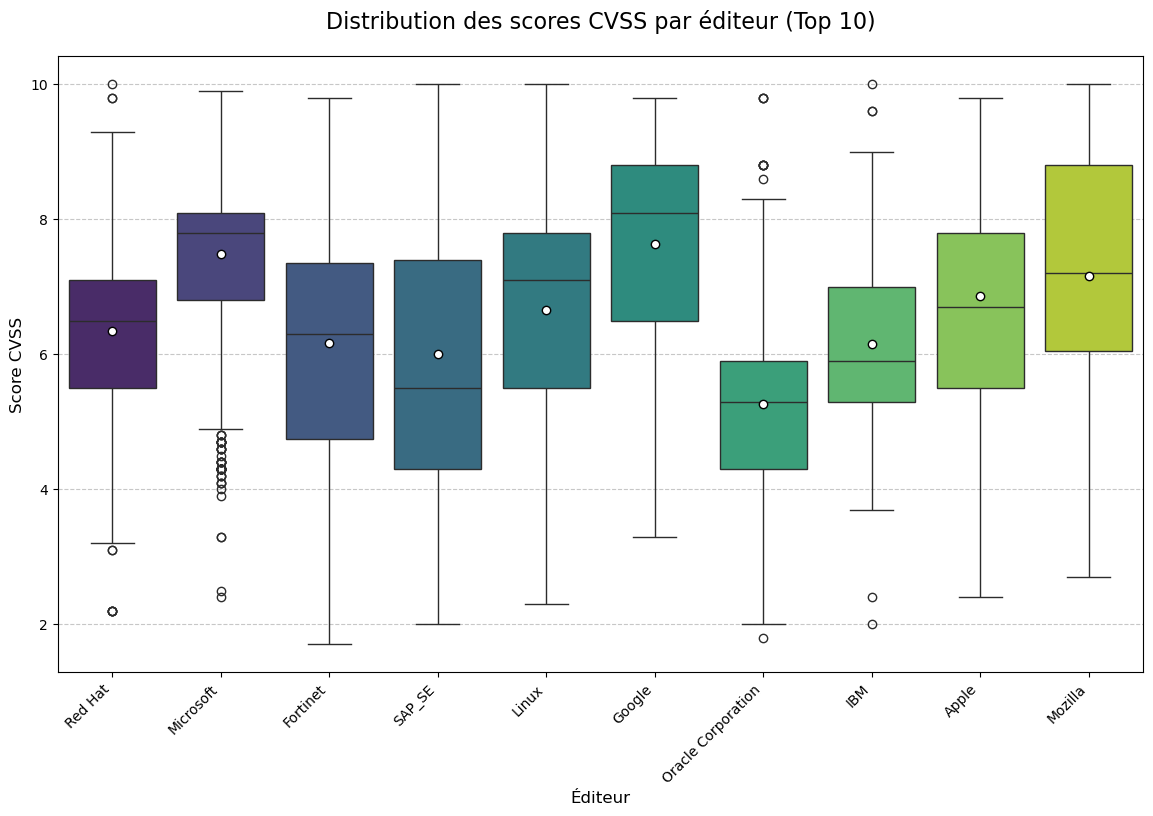

In [57]:
# Préparation des données
df['Score CVSS'] = pd.to_numeric(df['Score CVSS'], errors='coerce')
df = df.dropna(subset=['Score CVSS'])

# Filtrer les éditeurs valides
df = df[df['Éditeur/Vendor'].notna() & (df['Éditeur/Vendor'].str.lower() != 'non disponible')]

# Obtenir les 10 éditeurs les plus fréquents
top_ÉditeurVendors = df['Éditeur/Vendor'].value_counts().head(10).index

# Filtrer les données pour ces éditeurs
df_top_ÉditeurVendors = df[df['Éditeur/Vendor'].isin(top_ÉditeurVendors)]

# Création du boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='Éditeur/Vendor', 
    y='Score CVSS', 
    data=df_top_ÉditeurVendors,
    palette='viridis',
    showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black'}
)

# Personnalisation du graphique
plt.title('Distribution des scores CVSS par éditeur (Top 10)', fontsize=16, pad=20)
plt.xlabel('Éditeur', fontsize=12)
plt.ylabel('Score CVSS', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Sauvegarde et affichage
plt.savefig('cvss_boxplot_par_editeur.png', dpi=300, bbox_inches='tight')
plt.show()


On peut voir ici que le vulnérabilités les plus graves sont Microsoft, Google et Mozilla 

<h2>On cherche à savoir le type de bulletin</h2>

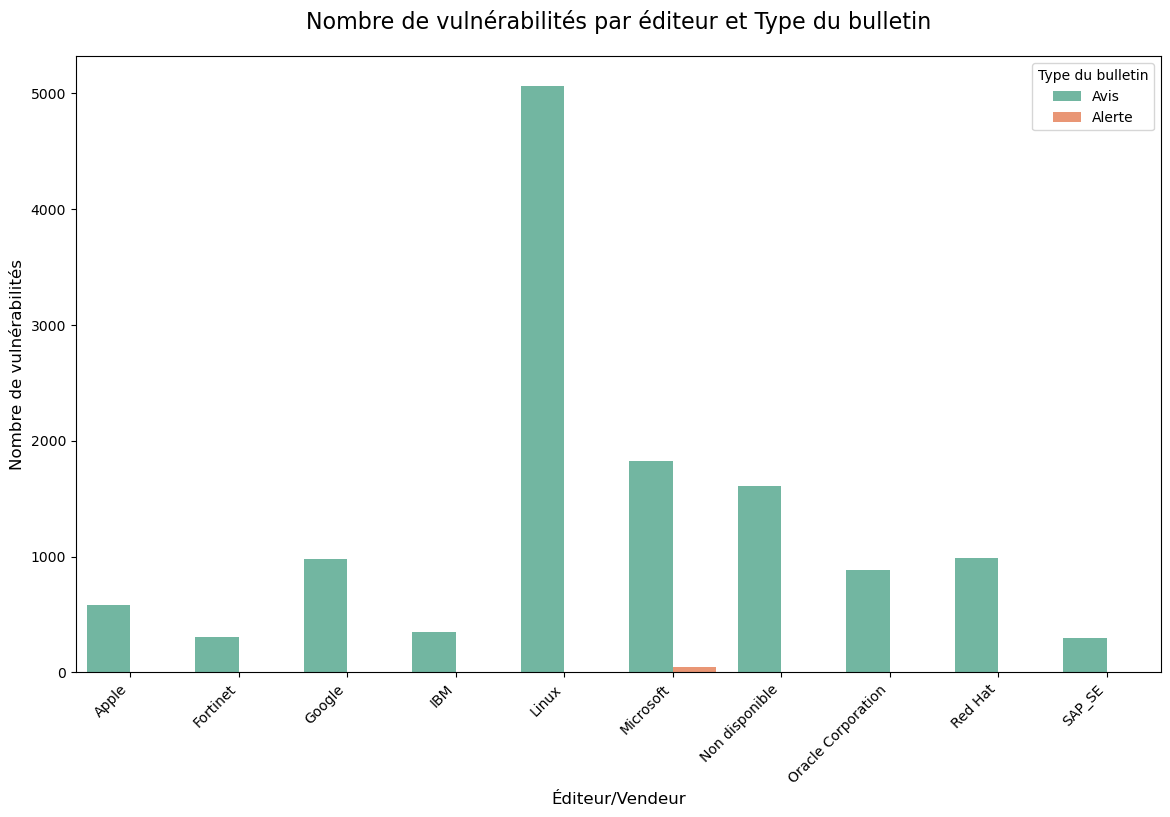

In [44]:

# Regrouper par Éditeur et Type du bulletin
editor_bulletin_counts = df.groupby(['Éditeur/Vendor', 'Type de bulletin']).size().reset_index(name='Nombre')

# Prendre les 10 éditeurs les plus fréquents (optionnel pour lisibilité)
top_editors = df['Éditeur/Vendor'].value_counts().head(10).index
editor_bulletin_counts = editor_bulletin_counts[editor_bulletin_counts['Éditeur/Vendor'].isin(top_editors)]

# Graphique
plt.figure(figsize=(14, 8))
sns.barplot(data=editor_bulletin_counts, x='Éditeur/Vendor', y='Nombre', hue='Type de bulletin', palette='Set2')

plt.title("Nombre de vulnérabilités par éditeur et Type du bulletin", fontsize=16, pad=20)
plt.xlabel("Éditeur/Vendeur", fontsize=12)
plt.ylabel("Nombre de vulnérabilités", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type du bulletin')

plt.savefig("vulnerabilites_par_editeur_et_bulletin.png", dpi=300)
plt.show()


encore une fois, on voit que la plupart des vulnérabilités viennent de Linux et qu'il y a presque uniquement des avis